In [32]:
# Cell 1: Imports and basic setup

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (12, 5)

# Base folder (same as your regression_new_rolling notebook)
BASE = "../../data/macro_processed_full"

In [33]:
# Cell 2: Monthly S&P 500 returns, T-bill returns, ERP and ERP_next

# Paths for price / yield data (adapt to your structure if needed)
path_sp = f"{BASE}/other/sp500_processed.csv"
path_rf = f"{BASE}/other/3m_yield_processed.csv"

# --- S&P 500 ---
sp = pd.read_csv(path_sp, parse_dates=["date"]).set_index("date").sort_index()

# sp500_processed.csv already has pct_change_mom in percent
# convert to simple monthly return in decimals
sp["sp500_ret"] = sp["pct_change_mom"] / 100.0
sp_m = sp[["sp500_ret"]].resample("M").last()

# --- 3M T-bill ---
rf = pd.read_csv(path_rf, parse_dates=["date"]).set_index("date").sort_index()
# value is annualized yield in percent
rf_ann = rf["value"] / 100.0
rf_m = ((1 + rf_ann) ** (1/12) - 1).to_frame("rf_ret").resample("M").last()

# align
idx = sp_m.index.intersection(rf_m.index)
sp_m = sp_m.loc[idx]
rf_m = rf_m.loc[idx]

# ERP_t = SP_t - RF_t  (current month)
model_df = sp_m.join(rf_m, how="inner")
model_df["erp"] = model_df["sp500_ret"] - model_df["rf_ret"]

# ERP_next_t = ERP_{t+1}, sp500_ret_next & rf_ret_next
model_df["erp_next"] = model_df["erp"].shift(-1)
model_df["sp500_ret_next"] = model_df["sp500_ret"].shift(-1)
model_df["rf_ret_next"] = model_df["rf_ret"].shift(-1)

# keep sample where next-month data exists
model_df = model_df.dropna()

# convert index to PeriodIndex (monthly)
model_df.index = model_df.index.to_period("M")

print("model_df shape:", model_df.shape)
print(model_df.head())

model_df shape: (430, 6)
         sp500_ret    rf_ret       erp  erp_next  sp500_ret_next  rf_ret_next
date                                                                         
1990-01  -0.068817  0.006434 -0.075251  0.002074        0.008539     0.006465
1990-02   0.008539  0.006465  0.002074  0.017767        0.024255     0.006488
1990-03   0.024255  0.006488  0.017767 -0.033375       -0.026887     0.006488
1990-04  -0.026887  0.006488 -0.033375  0.085547        0.091989     0.006442
1990-05   0.091989  0.006442  0.085547 -0.015320       -0.008886     0.006434


In [34]:
# Cell 3: Helper function to load macro series monthly

def load_monthly_series(path, name):
    """
    Load a macro series with a 'date' column and 'value' column,
    resample to monthly endpoints, and forward-fill.
    """
    df = (
        pd.read_csv(path, parse_dates=["date"])
        .set_index("date")
        .sort_index()
    )
    # keep 'value' as level, monthly frequency
    df = df[["value"]].rename(columns={"value": name})
    df_m = df.resample("M").last().ffill()
    return df_m

In [21]:
# ====================================
# BUILD ARX(3) FEATURES (STACKED 3 MONTHS)
# ====================================

target_col = "erp_next"

# All predictors we allow into the ARX model (including sp500_ret, rf_ret, erp, all macros)
base_predictors = [c for c in df.columns if c != target_col]

lags = 3  # ARX(3) – use current and previous 2 months of X

X_lagged_list = []
for lag in range(lags):
    shifted = df[base_predictors].shift(lag)
    shifted = shifted.add_suffix(f"_lag{lag+1}")   # lag1 = current, lag2 = t-1, lag3 = t-2 in calendar time
    X_lagged_list.append(shifted)

X_arx = pd.concat(X_lagged_list, axis=1)

# Combine with target and drop rows with missing lags
full = pd.concat([df[[target_col]], X_arx], axis=1).dropna()

y = full[target_col]
X = full.drop(columns=[target_col])

print("ARX(3) design matrix shape:", X.shape)
print("Sample period:", full.index.min(), "→", full.index.max())

ARX(3) design matrix shape: (245, 63)
Sample period: 2001-05 → 2021-09


In [35]:
# Cell 4: Load all macro variables (monthly, with ffill)

paths_macro = {
    # Inflation indices
    "cpi":          f"{BASE}/inflation/cpi_processed.csv",
    "pce":          f"{BASE}/inflation/PCE_price_index_processed.csv",
    "ppi":          f"{BASE}/inflation/PPI_inflation_processed.csv",

    # Real activity
    "indprod":      f"{BASE}/ec_growth/industrial_production_processed.csv",
    "retail_sales": f"{BASE}/ec_growth/retail_sales_processed.csv",
    "inventories":  f"{BASE}/ec_growth/tot_business_inventories_processed.csv",
    "export_px":    f"{BASE}/ec_growth/export_price_index_processed.csv",
    "import_px":    f"{BASE}/ec_growth/import_price_index_processed.csv",
    "unemp":        f"{BASE}/ec_growth/unemployment_processed.csv",

    # Money and policy
    "m2":           f"{BASE}/mon_policy/m2_real_money_supply_processed.csv",
    "fedfunds":     f"{BASE}/mon_policy/fedfunds_processed.csv",
    "discount_rate":f"{BASE}/mon_policy/fed_reserve_discount_rate_processed.csv",

    # Yields, spreads, vol
    "spread_10y_2y":f"{BASE}/mkt_vol/10y_2y_spread_processed.csv",
    "nat_fin_cond": f"{BASE}/mkt_vol/nat_fin_condition_indx_processed.csv",
    "nasdaq_vol":   f"{BASE}/mkt_vol/nasdaq_vol_indx_processed.csv",
    "hy_spread":    f"{BASE}/other/bofa_highyield_spread_processed.csv",
    "y2":           f"{BASE}/other/2y_yield_processed.csv",
    "y3m":          f"{BASE}/other/3m_yield_processed.csv",
    "y10":          f"{BASE}/other/10y_yield_processed.csv",
}

macro_m_list = []
for name, path in paths_macro.items():
    series_m = load_monthly_series(path, name)
    macro_m_list.append(series_m)

macro_m = pd.concat(macro_m_list, axis=1)

# convert to PeriodIndex
macro_m.index = macro_m.index.to_period("M")

print("macro_m shape:", macro_m.shape)
print(macro_m.head())

macro_m shape: (1355, 19)
         cpi  pce   ppi  indprod  retail_sales  inventories  export_px  import_px  unemp  m2  fedfunds  discount_rate  spread_10y_2y  nat_fin_cond  \
date                                                                                                                                                 
1913-01  NaN  NaN  12.1      NaN           NaN          NaN        NaN        NaN    NaN NaN       NaN            NaN            NaN           NaN   
1913-02  NaN  NaN  12.0      NaN           NaN          NaN        NaN        NaN    NaN NaN       NaN            NaN            NaN           NaN   
1913-03  NaN  NaN  12.0      NaN           NaN          NaN        NaN        NaN    NaN NaN       NaN            NaN            NaN           NaN   
1913-04  NaN  NaN  12.0      NaN           NaN          NaN        NaN        NaN    NaN NaN       NaN            NaN            NaN           NaN   
1913-05  NaN  NaN  11.9      NaN           NaN          NaN        NaN    

In [36]:
# Cell 5: Align macro data with returns and lag by 1 month

# lag everything by one month to mimic information delay:
# at the end of month t we know macro_{t-1}, ERP_t, etc
macro_lag = macro_m.shift(1)

# merge with target + returns
df = model_df.join(macro_lag, how="inner").dropna()

print("Final modeling dataframe:", df.shape)
df.head()

Final modeling dataframe: (247, 25)


,sp500_ret,rf_ret,erp,erp_next,sp500_ret_next,rf_ret_next,cpi,pce,ppi,indprod,retail_sales,inventories,export_px,import_px,unemp,m2,fedfunds,discount_rate,spread_10y_2y,nat_fin_cond,nasdaq_vol,hy_spread,y2,y3m,y10
date,,,,,,,,,,,,,,,,,,,,,,,,,
2001-03,-0.064205,0.003515,-0.067719,0.073581,0.076814,0.003234,176.0,75.048,137.4,91.2851,272627.0,1182045.0,100.2,99.9,4.2,2850.6,5.49,5.00,0.51,-0.28067,63.65,7.70,4.41,4.85,4.92
2001-04,0.076814,0.003234,0.073581,0.002114,0.005090,0.002976,176.1,75.055,135.9,91.0585,269820.0,1176840.0,100.0,98.3,4.3,2881.8,5.31,4.81,0.75,-0.25602,62.23,8.18,4.18,4.30,4.93
2001-05,0.005090,0.002976,0.002114,-0.028027,-0.025035,0.002992,176.4,75.187,136.4,90.7384,274410.0,1175468.0,99.9,97.8,4.4,2913.3,4.80,4.28,1.05,-0.33623,61.13,8.06,4.30,3.95,5.35
2001-06,-0.025035,0.002992,-0.028027,-0.013643,-0.010740,0.002903,177.3,75.385,136.8,90.2607,275769.0,1172056.0,99.6,98.0,4.3,2897.5,4.21,3.73,1.21,-0.42536,52.53,7.68,4.22,3.63,5.43
2001-07,-0.010740,0.002903,-0.013643,-0.066874,-0.064108,0.002766,177.7,75.518,135.5,89.7811,274474.0,1163409.0,99.4,97.6,4.5,2915.1,3.97,3.47,1.17,-0.46249,40.15,8.16,4.25,3.65,5.42


In [37]:
# Cell 6: Build ARX(3) design matrix

# X_base: all "information set" variables at month t
exclude_for_X = ["erp_next", "sp500_ret_next", "rf_ret_next"]
X_base = df.drop(columns=exclude_for_X)
y = df["erp_next"]

print("X_base shape:", X_base.shape)

# Build lags 0,1,2 for ARX(3): [X_t, X_{t-1}, X_{t-2}]
lags = [0, 1, 2]
X_lagged_list = []

for L in lags:
    tmp = X_base.shift(L).add_suffix(f"_L{L+1}")
    X_lagged_list.append(tmp)

X_arx = pd.concat(X_lagged_list, axis=1)

# retain next-month returns for trading
ret_next = df[["sp500_ret_next", "rf_ret_next"]]

# Combine into one big DataFrame and drop NaNs (from lags / shifts)
arx_df = pd.concat([X_arx, y, ret_next], axis=1).dropna()

print("ARX dataframe:", arx_df.shape)
arx_df.head()

X_base shape: (247, 22)
ARX dataframe: (245, 69)


,sp500_ret_L1,rf_ret_L1,erp_L1,cpi_L1,pce_L1,ppi_L1,indprod_L1,retail_sales_L1,inventories_L1,export_px_L1,import_px_L1,unemp_L1,m2_L1,fedfunds_L1,discount_rate_L1,...,import_px_L3,unemp_L3,m2_L3,fedfunds_L3,discount_rate_L3,spread_10y_2y_L3,nat_fin_cond_L3,nasdaq_vol_L3,hy_spread_L3,y2_L3,y3m_L3,y10_L3,erp_next,sp500_ret_next,rf_ret_next
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2001-05,0.005090,0.002976,0.002114,176.4,75.187,136.4,90.7384,274410.0,1175468.0,99.9,97.8,4.4,2913.3,4.80,4.28,...,99.9,4.2,2850.6,5.49,5.00,0.51,-0.28067,63.65,7.70,4.41,4.85,4.92,-0.028027,-0.025035,0.002992
2001-06,-0.025035,0.002992,-0.028027,177.3,75.385,136.8,90.2607,275769.0,1172056.0,99.6,98.0,4.3,2897.5,4.21,3.73,...,98.3,4.3,2881.8,5.31,4.81,0.75,-0.25602,62.23,8.18,4.18,4.30,4.93,-0.013643,-0.010740,0.002903
2001-07,-0.010740,0.002903,-0.013643,177.7,75.518,135.5,89.7811,274474.0,1163409.0,99.4,97.6,4.5,2915.1,3.97,3.47,...,97.8,4.4,2913.3,4.80,4.28,1.05,-0.33623,61.13,8.06,4.30,3.95,5.35,-0.066874,-0.064108,0.002766
2001-08,-0.064108,0.002766,-0.066874,177.4,75.493,133.4,89.2352,273098.0,1154938.0,99.0,96.1,4.6,2936.9,3.77,3.25,...,98.0,4.3,2897.5,4.21,3.73,1.21,-0.42536,52.53,7.68,4.22,3.63,5.43,-0.083702,-0.081723,0.001978
2001-09,-0.081723,0.001978,-0.083702,177.4,75.484,133.4,89.1570,275659.0,1152830.0,98.8,96.0,4.9,2955.9,3.65,3.16,...,97.6,4.5,2915.1,3.97,3.47,1.17,-0.46249,40.15,8.16,4.25,3.65,5.42,0.016407,0.018099,0.001692


In [38]:
# Cell 7: Chronological Train / Val / Test split

idx = arx_df.index

train_end = "2012-12"
val_end   = "2016-12"

train_mask = idx <= train_end
val_mask   = (idx > train_end) & (idx <= val_end)
test_mask  = idx > val_end

train_df = arx_df.loc[train_mask]
val_df   = arx_df.loc[val_mask]
test_df  = arx_df.loc[test_mask]

print("Train:", train_df.shape)
print("Val:  ", val_df.shape)
print("Test: ", test_df.shape)

# Split into X / y / returns
feature_cols = [c for c in arx_df.columns if c not in ["erp_next", "sp500_ret_next", "rf_ret_next"]]

X_train = train_df[feature_cols].copy()
y_train = train_df["erp_next"].copy()

X_val   = val_df[feature_cols].copy()
y_val   = val_df["erp_next"].copy()

X_test  = test_df[feature_cols].copy()
y_test  = test_df["erp_next"].copy()

ret_next_train = train_df[["sp500_ret_next", "rf_ret_next"]].copy()
ret_next_val   = val_df[["sp500_ret_next", "rf_ret_next"]].copy()
ret_next_test  = test_df[["sp500_ret_next", "rf_ret_next"]].copy()

Train: (140, 69)
Val:   (48, 69)
Test:  (57, 69)


In [39]:
# Cell 8: Standardize predictors (fit on TRAIN only)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

print("Scaled shapes:", X_train_sc.shape, X_val_sc.shape, X_test_sc.shape)

Scaled shapes: (140, 66) (48, 66) (57, 66)


In [40]:
# Cell 9: ARX(3) Linear Regression model (all variables, scaled)

lin_model = LinearRegression()
lin_model.fit(X_train_sc, y_train)

# Predictions
y_hat_train = lin_model.predict(X_train_sc)
y_hat_val   = lin_model.predict(X_val_sc)
y_hat_test  = lin_model.predict(X_test_sc)

# Helper for metrics
def summary_metrics(y_true, y_pred, label=""):
    r2  = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    print(f"{label}   R^2={r2:.4f},  RMSE={rmse:.4f},  MAE={mae:.4f}")

print("=== ARX(3) Linear Regression – Performance ===")
summary_metrics(y_train, y_hat_train, "Train")
summary_metrics(y_val,   y_hat_val,   "Val")
summary_metrics(y_test,  y_hat_test,  "Test")

=== ARX(3) Linear Regression – Performance ===
Train   R^2=0.6385,  RMSE=0.0271,  MAE=0.0222
Val   R^2=-2.4476,  RMSE=0.0541,  MAE=0.0460
Test   R^2=-10.5180,  RMSE=0.1529,  MAE=0.1222


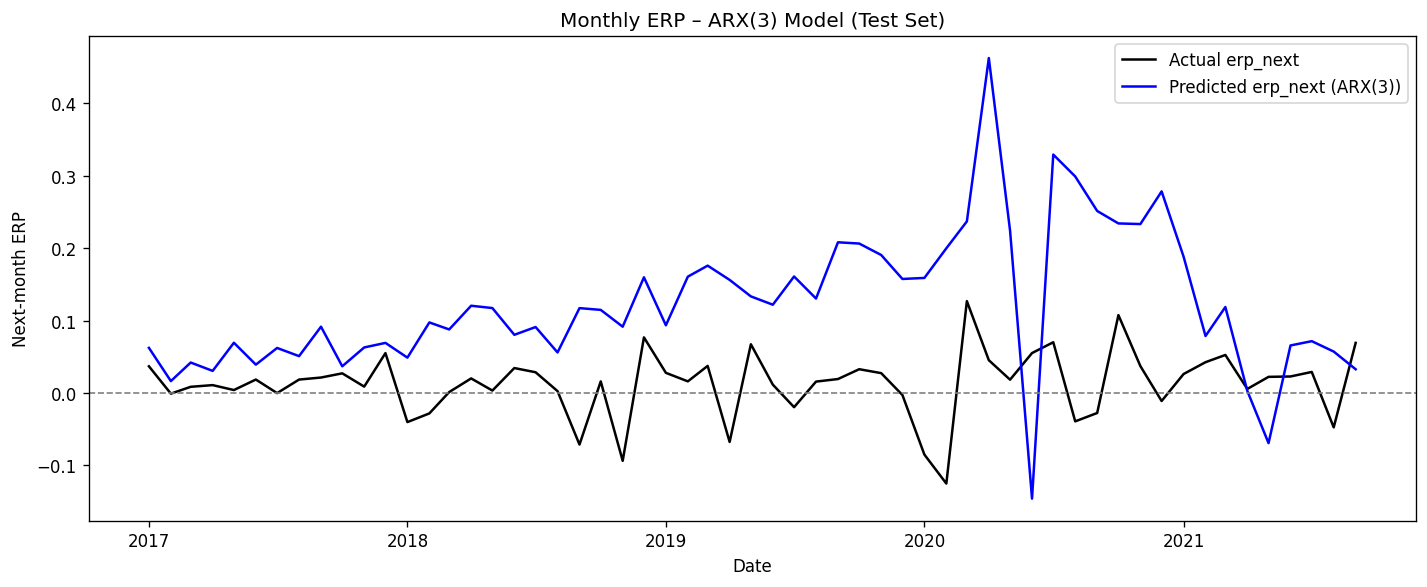

In [41]:
# Cell 10: Actual vs Predicted ERP_next on test set

idx_test_ts = y_test.index.to_timestamp()

plt.figure(figsize=(12,5))
plt.plot(idx_test_ts, y_test,      label="Actual erp_next", color="black")
plt.plot(idx_test_ts, y_hat_test,  label="Predicted erp_next (ARX(3))", color="blue")

plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.title("Monthly ERP – ARX(3) Model (Test Set)")
plt.ylabel("Next-month ERP")
plt.xlabel("Date")
plt.legend()
plt.tight_layout()
plt.show()

In [47]:
# ===================================
# Cell 11: Trading Strategies + Benchmarks
# ===================================

# --- Z-score of predicted ERP (based on TRAIN distribution) ---
mean_hat_train = np.mean(y_hat_train)
std_hat_train  = np.std(y_hat_train)

z_pred_test = (y_hat_test - mean_hat_train) / std_hat_train

# --- Strategy A: banded weights ---
def weight_bands(z):
    if z >= 2:   return 1.00
    elif z >= 1: return 0.75
    elif z > -1: return 0.50
    elif z > -2: return 0.25
    else:        return 0.00

wA_stock = pd.Series(z_pred_test, index=y_test.index).apply(weight_bands)
wA_rf    = 1 - wA_stock

# --- Strategy B: sign-based ---
def weight_sign(erp_pred):
    return 1.0 if erp_pred > 0 else 0.0

wB_stock = pd.Series(y_hat_test, index=y_test.index).apply(weight_sign)
wB_rf    = 1 - wB_stock

# --- Realized next-month returns ---
sp_next = ret_next_test["sp500_ret_next"]
rf_next = ret_next_test["rf_ret_next"]

# --- Portfolio returns ---
ret_A = wA_stock * sp_next + wA_rf * rf_next
ret_B = wB_stock * sp_next + wB_rf * rf_next

# ===================================
# BENCHMARKS
# ===================================

# 1. Buy & Hold (100% S&P)
ret_bench = sp_next.copy()

# 2. 50/50 static portfolio
ret_bench_50 = 0.50 * sp_next + 0.50 * rf_next

# 3. Constant mix using average dynamic weight of Strategy A
avg_wA = wA_stock.mean()      # average risky allocation
ret_bench_avg = avg_wA * sp_next + (1 - avg_wA) * rf_next

print("Mean monthly returns (test):")
print(f"Strategy A:     {ret_A.mean():.5f}")
print(f"Strategy B:     {ret_B.mean():.5f}")
print(f"Benchmark 100%: {ret_bench.mean():.5f}")
print(f"Benchmark 50/50:{ret_bench_50.mean():.5f}")
print(f"Benchmark avgW: {ret_bench_avg.mean():.5f}")

Mean monthly returns (test):
Strategy A:     0.01070
Strategy B:     0.01208
Benchmark 100%: 0.01344
Benchmark 50/50:0.00718
Benchmark avgW: 0.01179


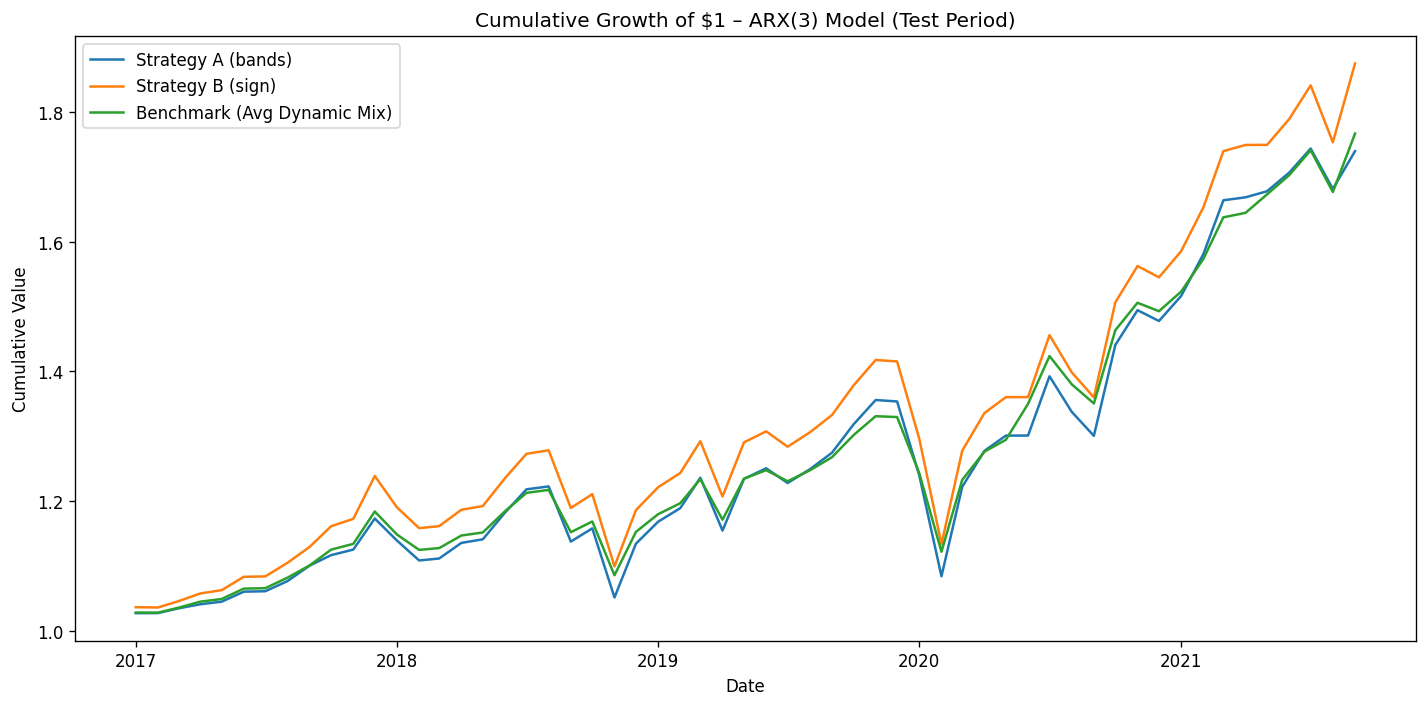

In [53]:
# ===================================
# Cell 12: Cumulative PnL Plot
# ===================================

idx_trade_ts = y_test.index.to_timestamp()

cum_A         = (1 + ret_A).cumprod()
cum_B         = (1 + ret_B).cumprod()
cum_bench     = (1 + ret_bench).cumprod()
cum_bench_50  = (1 + ret_bench_50).cumprod()
cum_bench_avg = (1 + ret_bench_avg).cumprod()

plt.figure(figsize=(12,6))
plt.plot(idx_trade_ts, cum_A,         label="Strategy A (bands)")
plt.plot(idx_trade_ts, cum_B,         label="Strategy B (sign)")
# plt.plot(idx_trade_ts, cum_bench,     label="Benchmark 100% S&P")
# plt.plot(idx_trade_ts, cum_bench_50,  label="Benchmark 50/50")
plt.plot(idx_trade_ts, cum_bench_avg, label="Benchmark (Avg Dynamic Mix)")

plt.title("Cumulative Growth of $1 – ARX(3) Model (Test Period)")
plt.ylabel("Cumulative Value")
plt.xlabel("Date")
plt.legend()
plt.tight_layout()
plt.show()

In [44]:
# Cell 13 (optional): LASSO ARX(3) on the same feature set

alphas = np.logspace(-3, 0, 40)  # from 0.001 to 1
tol = 1e-6

best_alpha = None
best_k = None
best_pipe = None

for a in sorted(alphas, reverse=True):  # try larger penalties first
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("lasso", Lasso(alpha=a, max_iter=50000, random_state=0))
    ])
    pipe.fit(X_train, y_train)
    coefs = pipe.named_steps["lasso"].coef_
    k = np.sum(np.abs(coefs) > tol)

    if k >= 6:         # at least 6 nonzero predictors
        best_alpha = a
        best_k = k
        best_pipe = pipe
        break

if best_pipe is None:
    # fallback: weakest penalty
    a = alphas.min()
    best_pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("lasso", Lasso(alpha=a, max_iter=50000, random_state=0))
    ])
    best_pipe.fit(X_train, y_train)
    coefs = best_pipe.named_steps["lasso"].coef_
    best_alpha = a
    best_k = np.sum(np.abs(coefs) > tol)

print("\n=== LASSO ARX(3) ===")
print("alpha:", best_alpha)
print("nonzero coefficients:", best_k)

# Evaluate LASSO
y_hat_train_L = best_pipe.predict(X_train)
y_hat_val_L   = best_pipe.predict(X_val)
y_hat_test_L  = best_pipe.predict(X_test)

summary_metrics(y_train, y_hat_train_L, "Train (LASSO)")
summary_metrics(y_val,   y_hat_val_L,   "Val   (LASSO)")
summary_metrics(y_test,  y_hat_test_L,  "Test  (LASSO)")

# If later you want to trade with LASSO instead of OLS, just
# replace y_hat_test by y_hat_test_L in Cell 11.


=== LASSO ARX(3) ===
alpha: 0.003455107294592218
nonzero coefficients: 6
Train (LASSO)   R^2=0.1080,  RMSE=0.0425,  MAE=0.0325
Val   (LASSO)   R^2=-0.1347,  RMSE=0.0311,  MAE=0.0251
Test  (LASSO)   R^2=-0.0023,  RMSE=0.0451,  MAE=0.0308


In [ ]:
# ================================
# L1. LASSO Trading Strategies
# ================================

# Predicted ERP_next from LASSO in the test set
y_hat_test_L = pd.Series(y_hat_test_L, index=y_test.index)

# --- Z-score of LASSO predictions based on TRAIN SAMPLE ---
mean_L_train = np.mean(y_hat_train_L)
std_L_train  = np.std(y_hat_train_L)

z_pred_test_L = (y_hat_test_L - mean_L_train) / std_L_train

# ---------- Strategy A (bands) ----------
def weight_bands(z):
    if z >= 2:   return 1.00
    elif z >= 1: return 0.75
    elif z > -1: return 0.50
    elif z > -2: return 0.25
    else:        return 0.00

wA_stock_L = z_pred_test_L.apply(weight_bands)
wA_rf_L    = 1 - wA_stock_L

# ---------- Strategy B (sign of ERP_next) ----------
def weight_sign(x):
    return 1.0 if x > 0 else 0.0

wB_stock_L = y_hat_test_L.apply(weight_sign)
wB_rf_L    = 1 - wB_stock_L

# Realized next-month returns
sp_next = ret_next_test["sp500_ret_next"]
rf_next = ret_next_test["rf_ret_next"]

# Portfolio realized returns for LASSO
ret_A_L = wA_stock_L * sp_next + wA_rf_L * rf_next
ret_B_L = wB_stock_L * sp_next + wB_rf_L * rf_next

# BENCHMARKS (LASSO)
ret_bench     = sp_next.copy()
ret_bench_50  = 0.50 * sp_next + 0.50 * rf_next
avg_wA_L      = wA_stock_L.mean()
ret_bench_avg = avg_wA_L * sp_next + (1 - avg_wA_L) * rf_next

print("Mean monthly returns (test period):")
print(f"Strategy A (LASSO): {ret_A_L.mean():.5f}")
print(f"Strategy B (LASSO): {ret_B_L.mean():.5f}")
print(f"Benchmark 100%:      {ret_bench.mean():.5f}")
print(f"Benchmark 50/50:     {ret_bench_50.mean():.5f}")
print(f"Benchmark avgW:      {ret_bench_avg.mean():.5f}")

Mean monthly returns (test period):
Strategy A (LASSO): 0.01138
Strategy B (LASSO): 0.01209
Benchmark 100%:      0.01344
Benchmark 50/50:     0.00718
Benchmark avgW:      0.01064


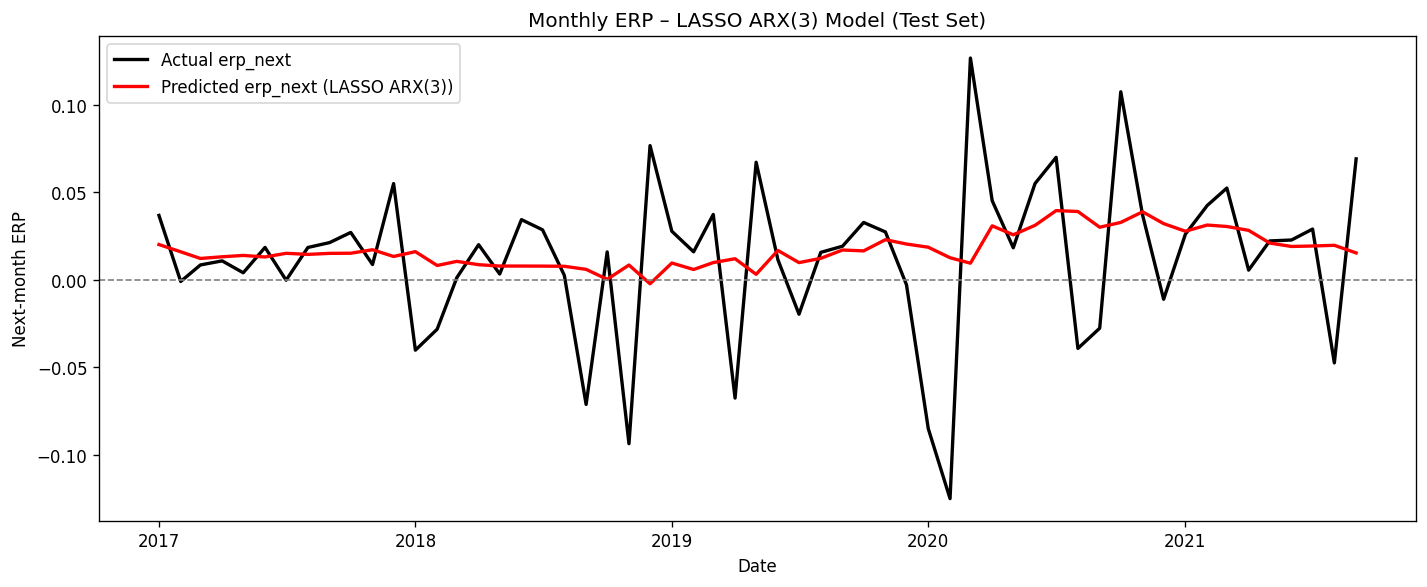

In [55]:
# ============================================
# LASSO: Actual vs Predicted ERP_next (Test Set)
# ============================================

idx_test_ts = y_test.index.to_timestamp()

plt.figure(figsize=(12,5))
plt.plot(idx_test_ts, y_test,          label="Actual erp_next", color="black", linewidth=2)
plt.plot(idx_test_ts, y_hat_test_L,    label="Predicted erp_next (LASSO ARX(3))", 
         color="red", linewidth=2)

plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.title("Monthly ERP – LASSO ARX(3) Model (Test Set)")
plt.ylabel("Next-month ERP")
plt.xlabel("Date")
plt.legend()
plt.tight_layout()
plt.show()

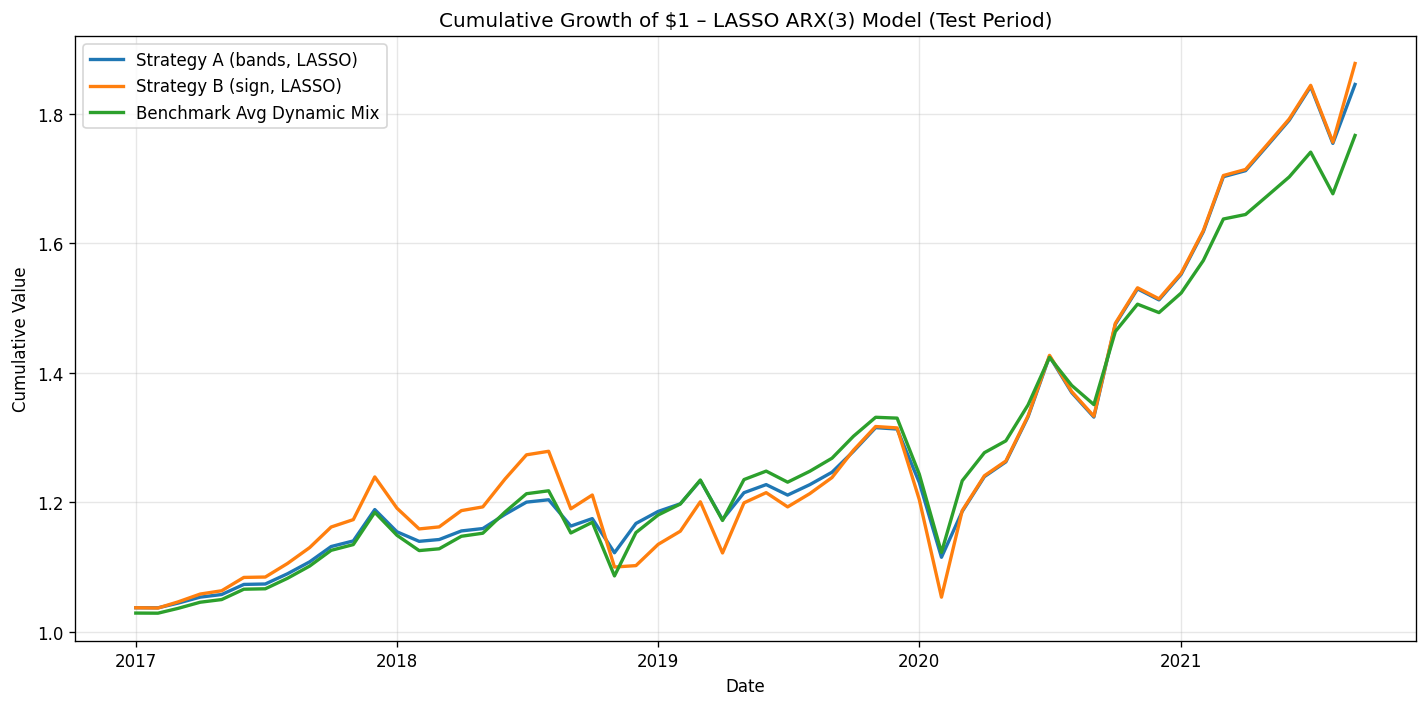

In [52]:
idx_ts = y_test.index.to_timestamp()

cum_A_L         = (1 + ret_A_L).cumprod()
cum_B_L         = (1 + ret_B_L).cumprod()
cum_bench_L     = (1 + ret_bench).cumprod()
cum_bench_50_L  = (1 + ret_bench_50).cumprod()
cum_bench_avg_L = (1 + ret_bench_avg).cumprod()

plt.figure(figsize=(12,6))
plt.plot(idx_ts, cum_A_L,         label="Strategy A (bands, LASSO)", linewidth=2)
plt.plot(idx_ts, cum_B_L,         label="Strategy B (sign, LASSO)", linewidth=2)
# plt.plot(idx_ts, cum_bench_L,     label="Benchmark 100% S&P", linewidth=2)
# plt.plot(idx_ts, cum_bench_50_L,  label="Benchmark 50/50", linewidth=2)
plt.plot(idx_ts, cum_bench_avg_L, label="Benchmark Avg Dynamic Mix", linewidth=2)

plt.title("Cumulative Growth of $1 – LASSO ARX(3) Model (Test Period)")
plt.xlabel("Date")
plt.ylabel("Cumulative Value")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()